# Curiosity and Novelty

This notebook explains curiosity as a mechanistic novelty drive in AXIS CMS.

Primary focus:
- spatial novelty
- sensory novelty
- observation buffer and visit-count world model
- curiosity activation and action scoring
- why curiosity in AXIS is modeled this way rather than as a universal theory of curiosity

The main artifact source is the `system_aw-baseline` workspace, specifically the `curiosity-arbitration` series.


In [1]:
from _bootstrap import setup_notebook

ROOT = setup_notebook()

ROOT


PosixPath('/workspaces/axis-system-cms')

## Why Add Curiosity At All?

System A already gave AXIS a homeostatic baseline: behavior can become adaptive even with only hunger, local perception, and a policy. But System A also made a limit visible: without an explicit exploration pressure, behavior remains strongly tied to immediate local resource structure.

That motivates curiosity, but not as a vague slogan. In AXIS, curiosity is introduced because we want a mechanism that can do all of the following at once:

- favor movement toward what is less familiar or more changing
- remain local and mechanistic rather than symbolic
- stay fully traceable at the step level
- compose cleanly with hunger instead of replacing it

So the point of curiosity here is not to model the full psychology of curiosity. It is to add a mathematically explicit exploration pressure to the baseline architecture.


## Biological Motivation, Strong But Careful

Biologically, curiosity-like behavior is often associated with exploration, orienting toward novelty, information seeking, and reduced behavioral fixation on already-known states. AXIS borrows this family resemblance, but in a highly reduced form.

The biologically relevant inspirations are:

- organisms often move differently in familiar versus unfamiliar environments
- novelty itself can function as a behavioral attractor
- exploration is often strongest when immediate survival pressure is not maximal
- repeated exposure tends to reduce exploratory pull

The important non-claim is just as important:

- AXIS is **not** claiming that all biological curiosity is count-based or buffer-based
- it is **not** claiming that novelty seeking is the same as epistemic reasoning
- it is **not** claiming that curiosity reduces to one scalar quantity

Instead, AXIS chooses one specific mechanistic interpretation:

> curiosity as attraction toward novelty gradients that can be computed from local sensory change and local familiarity structure.


## This Curiosity Model Is One Model, Not Curiosity In General

There are several important families of curiosity-like mechanisms in the broader literature and engineering landscape.

| Family | Typical signal | What it emphasizes | How AXIS differs here |
| --- | --- | --- | --- |
| count-based exploration | state or state-action visitation counts | familiarity / rarity | AXIS uses a **local visit-count world model**, not global count tables over the whole state space |
| prediction-error / surprise | mismatch between expected and observed outcome | violated expectation | AXIS curiosity here is novelty-driven, not prediction-error-driven |
| information gain / uncertainty reduction | expected reduction in uncertainty | epistemic value | AXIS does not estimate uncertainty over latent world models in `system_aw` |
| intrinsic reward in RL | reward bonus for novelty/surprise | optimization-time exploration incentives | AXIS curiosity is a direct drive component, not an auxiliary reward |

This is why later predictive systems matter.

In `System C` and `System C+W`, prediction becomes part of the architecture. That enables a different class of exploratory or modulatory effects: not just attraction to novelty, but behavior shaped by confidence, frustration, and predictive mismatch. So prediction is being deliberately *teased apart* from curiosity here rather than folded into it too early.


## Why Curiosity Is Implemented This Way In AXIS

The AXIS implementation makes a specific design tradeoff. Curiosity should be:

- **mechanistic**: built from explicit formulas rather than opaque learned value estimates
- **local**: dependent on local observation and local world-model structure
- **traceable**: every component should appear in persisted decision traces
- **composable**: it should combine with hunger through a visible arbitration rule
- **minimal**: rich enough to create exploration gradients, simple enough to reason about

That leads to four pieces:

1. a **visit-count world model** for spatial familiarity
2. an **observation buffer** for sensory novelty
3. a **composite novelty signal** blending spatial and sensory terms
4. a **curiosity activation** term that weakens when recent experience is already highly novel or variable


In [2]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import display

from research.lib.plotting import bar_plot, lines_plot
from axis.framework.persistence import ExperimentRepository
from axis.systems.construction_kit.arbitration.scoring import combine_drive_scores
from axis.systems.construction_kit.arbitration.weights import compute_maslow_weights
from axis.systems.construction_kit.drives.curiosity import (
    compute_composite_novelty,
    compute_curiosity_activation,
    compute_novelty_saturation,
    compute_sensory_novelty,
)
from axis.systems.construction_kit.drives.hunger import HungerDrive
from axis.systems.construction_kit.memory.types import BufferEntry, ObservationBuffer, WorldModelState
from axis.systems.construction_kit.memory.world_model import (
    create_world_model,
    spatial_novelty,
    update_world_model,
)
from axis.systems.construction_kit.observation.types import CellObservation, Observation
from axis.systems.system_a.types import AgentState

SERIES_ROOT = ROOT / 'research' / 'workspaces' / 'system_aw-baseline' / 'series' / 'curiosity-arbitration'
SERIES_SUMMARY_PATH = SERIES_ROOT / 'measurements' / 'series-summary.json'
RESULTS_ROOT = SERIES_ROOT / 'results'

series_summary = json.loads(SERIES_SUMMARY_PATH.read_text())
experiments = {experiment['label']: experiment for experiment in series_summary['experiments']}
repo = ExperimentRepository(RESULTS_ROOT)

selected_labels = [
    'aw-a-reduction-check',
    'aw-baseline',
    'aw-exploration-biased',
    'aw-spatial-novelty-dominant',
    'aw-sensory-novelty-dominant',
]

series_data = {}
for label in selected_labels:
    exp = experiments[label]
    expid = exp['candidate_experiment_id']
    exp_root = RESULTS_ROOT / expid
    series_data[label] = {
        'experiment_id': expid,
        'summary': exp,
        'config': json.loads((exp_root / 'experiment_config.json').read_text()),
        'behavior_metrics': json.loads((exp_root / 'runs' / 'run-0000' / 'behavior_metrics.json').read_text()),
    }

baseline_label = 'aw-baseline'
baseline_expid = experiments[baseline_label]['candidate_experiment_id']
BASELINE_EPISODE_INDEX = 1
BASELINE_EPISODE_PATH = RESULTS_ROOT / baseline_expid / 'runs' / 'run-0000' / 'episodes' / f'episode_{BASELINE_EPISODE_INDEX:04d}.json'
baseline_episode = repo.load_episode_trace(baseline_expid, 'run-0000', BASELINE_EPISODE_INDEX).model_dump()

selected_experiments_df = pd.DataFrame(
    [
        {'label': label, 'experiment_id': series_data[label]['experiment_id']}
        for label in selected_labels
    ]
)

display(selected_experiments_df)
print('Series:', series_summary['series_title'])
print('Trace horizon: 400 steps')
print('Baseline episode artifact:', BASELINE_EPISODE_PATH.relative_to(ROOT))
print('Baseline experiment ID:', baseline_expid)

,label,experiment_id
0,aw-a-reduction-check,d399e549ce624851ad46de2b8aa6ae84
1,aw-baseline,f6007c77281445359cd80f28805f8f35
2,aw-exploration-biased,b9dd7afa48f04cf5be38754a7792b713
3,aw-spatial-novelty-dominant,d3545525ae5c45f994d87f6f8dd64bb8
4,aw-sensory-novelty-dominant,bee2ea945d4f4f42b19eba41d940e903


Series: System A+W Curiosity and Arbitration Series
Trace horizon: 400 steps
Baseline episode artifact: research/workspaces/system_aw-baseline/series/curiosity-arbitration/results/f6007c77281445359cd80f28805f8f35/runs/run-0000/episodes/episode_0001.json
Baseline experiment ID: f6007c77281445359cd80f28805f8f35


## The Mathematical Pieces

The curiosity mechanism in `system_aw` is easiest to understand as a pipeline.

### 1. Spatial novelty

For each cardinal direction:

$$
\nu_{\text{dir}}^{\text{spatial}} = \frac{1}{1 + w_t(\hat{p}_t + \Delta(\text{dir}))}
$$

where:

- `w(...)` is the visit count at the neighbor position in the agent-relative world model
- `k` is `novelty_sharpness`

Interpretation:

- unvisited neighbors have novelty `1.0`
- revisited neighbors decay smoothly toward `0`
- larger `k` sharpens the preference for unvisited space

### 2. Sensory novelty

For each direction:

$$
\nu_{\text{dir}}^{\text{sensory}} = |r_{\text{dir}}(t) - \bar{r}_{\text{dir}}|
$$

Interpretation:

- if the current local sensory resource value differs from recent history, novelty rises
- this is not prediction error in the full sense; it is a local change-sensitive signal derived from recent observations

### 3. Composite novelty

$$
\nu_{\text{dir}} = \alpha \cdot \nu_{\text{dir}}^{\text{spatial}} + (1 - \alpha) \cdot \nu_{\text{dir}}^{\text{sensory}}
$$

where `alpha = spatial_sensory_balance`.

### 4. Novelty saturation and curiosity activation

AXIS also modulates curiosity strength using recent variability in the buffer:

$$
d_C(t) = \mu_C \cdot (1 - \bar{\nu}_t)
$$

where $\mu_C \in [0, 1]$ and $\bar{\nu}_t$ is the buffer-based novelty saturation term.

### 5. Curiosity action contributions

Movement actions receive the composite novelty values directly, while `consume` and `stay` are penalized by `explore_suppression`.

This matters a lot conceptually: curiosity in AXIS is not just “be interested”. It is specifically a **movement-biased novelty drive**.



,visit_count,k=1.0,k=1.5,k=2.0
0,0,1.000000,1.000000,1.000000
1,1,0.500000,0.353553,0.250000
2,2,0.333333,0.192450,0.111111
3,3,0.250000,0.125000,0.062500
4,4,0.200000,0.089443,0.040000
5,5,0.166667,0.068041,0.027778
6,6,0.142857,0.053995,0.020408
7,7,0.125000,0.044194,0.015625
8,8,0.111111,0.037037,0.012346
9,9,0.100000,0.031623,0.010000


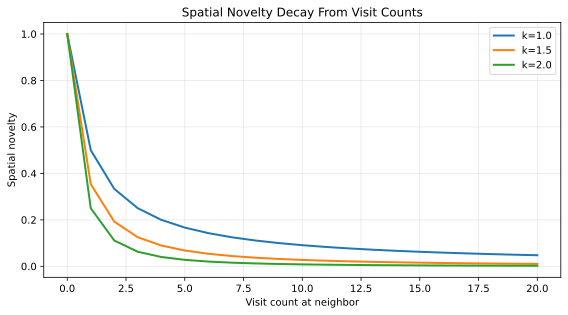

In [3]:
visit_counts = list(range(0, 21))
spatial_decay_df = pd.DataFrame({'visit_count': visit_counts})
for k in [1.0, 1.5, 2.0]:
    spatial_decay_df[f'k={k}'] = [1.0 / (1.0 + w) ** k for w in visit_counts]

display(spatial_decay_df.head(10))

fig, ax = lines_plot(
    [
        {'x': spatial_decay_df['visit_count'], 'y': spatial_decay_df['k=1.0'], 'label': 'k=1.0'},
        {'x': spatial_decay_df['visit_count'], 'y': spatial_decay_df['k=1.5'], 'label': 'k=1.5'},
        {'x': spatial_decay_df['visit_count'], 'y': spatial_decay_df['k=2.0'], 'label': 'k=2.0'},
    ],
    title='Spatial Novelty Decay From Visit Counts',
    xlabel='Visit count at neighbor',
    ylabel='Spatial novelty',
)


This plot gives the intuitive shape of the visit-count model.

Exploration is not being driven by randomness here. It is being driven by a mathematically explicit gradient:

- unvisited space is maximally attractive
- revisited space becomes progressively less attractive
- `novelty_sharpness` controls how aggressively familiarity suppresses that attraction


## Didactic World-Model Example

The visit-count world model is not a full map of the world. It is an agent-relative familiarity structure built by dead reckoning.

That means it stores neither absolute global coordinates nor semantic knowledge about resources. It stores only:

- a relative position estimate
- counts of how often relative positions have been visited

The next cell simulates a tiny path to make that concrete.


In [4]:
toy_world_model = create_world_model()
path_actions = [
    ('up', True),
    ('left', True),
    ('left', True),
    ('right', True),
    ('stay', False),
    ('down', True),
    ('left', True),
]
for action, moved in path_actions:
    toy_world_model = update_world_model(toy_world_model, action, moved)

toy_visit_df = pd.DataFrame(
    [
        {'x': pos[0], 'y': pos[1], 'visit_count': count}
        for pos, count in toy_world_model.visit_counts
    ]
).sort_values(['y', 'x']).reset_index(drop=True)

display(toy_visit_df)


,x,y,visit_count
0,-2,0,1
1,-1,0,1
2,0,0,1
3,-2,1,1
4,-1,1,3
5,0,1,1


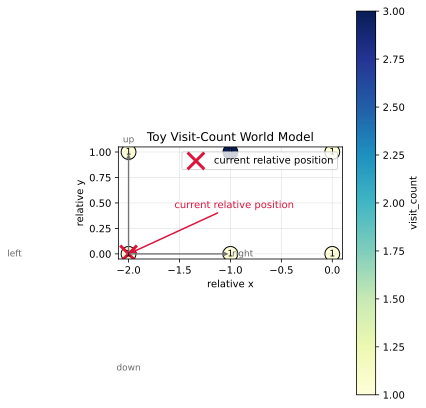

In [5]:
plt = __import__('matplotlib.pyplot').pyplot
fig, ax = plt.subplots(figsize=(6.2, 6.2))
scatter = ax.scatter(
    toy_visit_df['x'],
    toy_visit_df['y'],
    s=220,
    c=toy_visit_df['visit_count'],
    cmap='YlGnBu',
    edgecolors='black',
)
for row in toy_visit_df.itertuples(index=False):
    ax.text(row.x, row.y, str(int(row.visit_count)), ha='center', va='center', fontsize=9)

current_x, current_y = toy_world_model.relative_position
ax.scatter([current_x], [current_y], s=280, marker='x', color='crimson', linewidths=3, label='current relative position')
ax.annotate(
    'current relative position',
    xy=(current_x, current_y),
    xytext=(current_x + 0.45, current_y + 0.45),
    arrowprops={'arrowstyle': '->', 'color': 'crimson', 'lw': 1.5},
    color='crimson',
    fontsize=10,
)

for direction, (dx, dy) in {
    'up': (0, 1),
    'down': (0, -1),
    'left': (-1, 0),
    'right': (1, 0),
}.items():
    ax.annotate(
        '',
        xy=(current_x + dx, current_y + dy),
        xytext=(current_x, current_y),
        arrowprops={'arrowstyle': '->', 'color': 'dimgray', 'lw': 1.4, 'alpha': 0.9},
    )
    ax.text(
        current_x + 1.12 * dx,
        current_y + 1.12 * dy,
        direction,
        color='dimgray',
        fontsize=9,
        ha='center',
        va='center',
    )

ax.set_title('Toy Visit-Count World Model')
ax.set_xlabel('relative x')
ax.set_ylabel('relative y')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='upper right')
fig.colorbar(scatter, ax=ax, label='visit_count')
fig.tight_layout()



### How To Read This Plot

This figure is not a map of the external world. It is a visualization of the **agent-relative visit-count memory**.

- each point `(x, y)` is a **relative position** in the internal world model
- the number printed inside a point is the **visit count** for that relative position
- the color intensity shows the same thing visually: darker means **visited more often**
- the red `X` marks the agent's **current relative position** in that internal model
- the gray arrows indicate the four cardinal neighbor directions that curiosity can evaluate next

The key interpretation is:

- low-count neighbor positions are **more spatially novel**
- high-count neighbor positions are **less spatially novel**
- curiosity therefore prefers directions that point toward less-visited relative positions

So this plot should be read as a **familiarity landscape**, not as a semantic resource map.

This is one reason the AXIS curiosity model is interestingly constrained.

The world model does **not** know where food "ought" to be. It does not estimate uncertainty over a latent map. It only knows which relative regions have been experienced more or less often.



## Sensory Novelty And The Observation Buffer

Spatial novelty alone would make curiosity purely familiarity-based. AXIS adds a second channel: sensory novelty.

This uses the observation buffer rather than the world model. The idea is simple:

- if the local directional resource pattern looks different from recent history, that direction is sensorily novel
- if it looks similar to recent history, sensory novelty is low

The buffer therefore provides short-horizon experiential context without requiring a predictive model.


In [6]:
def make_observation(*, current=0.0, up=0.0, down=0.0, left=0.0, right=0.0,
                     current_trav=1.0, up_trav=1.0, down_trav=1.0, left_trav=1.0, right_trav=1.0):
    return Observation(
        current=CellObservation(traversability=current_trav, resource=current),
        up=CellObservation(traversability=up_trav, resource=up),
        down=CellObservation(traversability=down_trav, resource=down),
        left=CellObservation(traversability=left_trav, resource=left),
        right=CellObservation(traversability=right_trav, resource=right),
    )

buffer = ObservationBuffer(
    entries=(
        BufferEntry(timestep=0, observation=make_observation(up=0.0, down=0.0, left=0.1, right=0.0)),
        BufferEntry(timestep=1, observation=make_observation(up=0.0, down=0.0, left=0.0, right=0.0)),
        BufferEntry(timestep=2, observation=make_observation(up=0.1, down=0.0, left=0.0, right=0.0)),
    ),
    capacity=50,
)
current_observation = make_observation(up=0.0, down=0.5, left=0.0, right=0.0)

sensory = compute_sensory_novelty(current_observation, buffer)
saturation = compute_novelty_saturation(buffer)

buffer_mean_df = pd.DataFrame(
    [
        ('up', sum(entry.observation.up.resource for entry in buffer.entries) / len(buffer.entries), current_observation.up.resource, sensory[0]),
        ('down', sum(entry.observation.down.resource for entry in buffer.entries) / len(buffer.entries), current_observation.down.resource, sensory[1]),
        ('left', sum(entry.observation.left.resource for entry in buffer.entries) / len(buffer.entries), current_observation.left.resource, sensory[2]),
        ('right', sum(entry.observation.right.resource for entry in buffer.entries) / len(buffer.entries), current_observation.right.resource, sensory[3]),
    ],
    columns=['direction', 'buffer_mean_resource', 'current_resource', 'sensory_novelty'],
)

display(buffer_mean_df)
print('novelty_saturation:', saturation)


,direction,buffer_mean_resource,current_resource,sensory_novelty
0,up,0.033333,0.0,0.033333
1,down,0.000000,0.5,0.500000
2,left,0.033333,0.0,0.033333
3,right,0.000000,0.0,0.000000


novelty_saturation: 0.022222222222222227


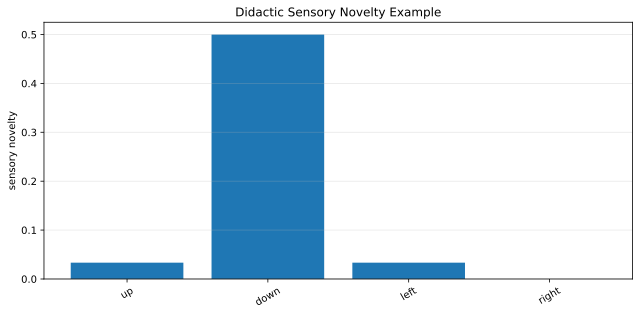

In [7]:
fig, ax = bar_plot(
    buffer_mean_df['direction'],
    buffer_mean_df['sensory_novelty'],
    title='Didactic Sensory Novelty Example',
    ylabel='sensory novelty',
)


This cell shows the distinction clearly.

- the **buffer mean** represents recent sensory expectation in a very weak form
- the **current resource pattern** is compared against that recent baseline
- the largest mismatch produces the largest sensory novelty

This is close enough to change sensitivity to be biologically suggestive, but it is still much simpler than full predictive surprise.


## Composite Novelty: Spatial And Sensory Together

Now the two novelty channels are blended. This is one of the most important design decisions in the AXIS curiosity model.

Why not use only spatial novelty?
Because exploration should not respond only to "where have I been?" but also to "what locally changed?"

Why not use only sensory novelty?
Because pure change sensitivity can become myopic and overly tied to fluctuating local stimuli.

The blend parameter `alpha` is therefore a modeling choice about what kind of curiosity we want to instantiate.


In [8]:
example_spatial = (1.0, 0.35, 0.2, 0.8)
example_sensory = (0.05, 0.60, 0.10, 0.15)
alpha_values = {'spatial_dominant_alpha=0.95': 0.95, 'baseline_alpha=0.50': 0.50, 'sensory_dominant_alpha=0.25': 0.25}

composite_rows = []
for label, alpha in alpha_values.items():
    composite = compute_composite_novelty(example_spatial, example_sensory, alpha)
    for direction, value in zip(['up', 'down', 'left', 'right'], composite):
        composite_rows.append(
            {'profile': label, 'direction': direction, 'composite_novelty': value}
        )

composite_df = pd.DataFrame(composite_rows)
display(composite_df.pivot(index='direction', columns='profile', values='composite_novelty'))


profile,baseline_alpha=0.50,sensory_dominant_alpha=0.25,spatial_dominant_alpha=0.95
direction,,,
down,0.475,0.5375,0.3625
left,0.150,0.1250,0.1950
right,0.475,0.3125,0.7675
up,0.525,0.2875,0.9525


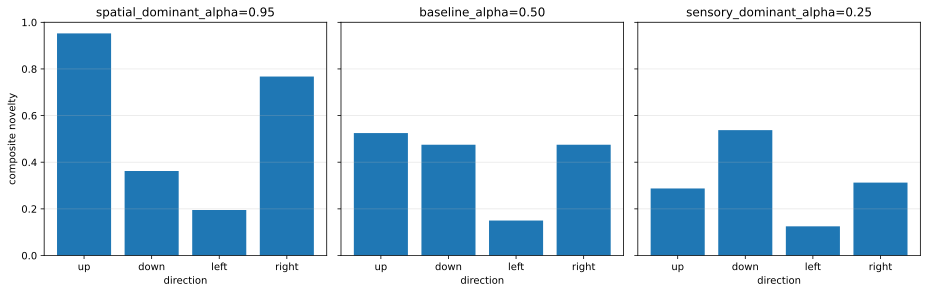

In [9]:
profiles = list(alpha_values.keys())
fig, axes = __import__('matplotlib.pyplot').pyplot.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, profile in zip(axes, profiles):
    subset = composite_df[composite_df['profile'] == profile]
    ax.bar(subset['direction'], subset['composite_novelty'])
    ax.set_title(profile)
    ax.set_xlabel('direction')
    ax.grid(True, axis='y', alpha=0.3)
axes[0].set_ylabel('composite novelty')
fig.tight_layout()


The effect of `alpha` is not cosmetic. It changes what the system treats as exploratory opportunity.

- high `alpha` makes curiosity mostly familiarity-seeking in space
- low `alpha` makes curiosity more reactive to sensory change
- intermediate values create a hybrid novelty signal

That is why `aw-spatial-novelty-dominant` and `aw-sensory-novelty-dominant` are genuinely different behavioral experiments rather than mere parameter noise.


## Real `system_aw` Trace: Curiosity In Action

The next trace section uses the current `aw-baseline` configuration from the rerun `curiosity-arbitration` series. Concretely, the trace anchor is experiment `$f6007c77281445359cd80f28805f8f35$` with a **400-step horizon**.

We will look at a concrete step where:

- hunger is already present
- curiosity is still active
- local resource and novelty signals both matter

This makes it possible to see how curiosity changes movement preferences rather than just existing in parallel.


In [10]:
baseline_step = baseline_episode['steps'][20]
baseline_decision = baseline_step['system_data']['decision_data']
baseline_trace = baseline_step['system_data']['trace_data']

trace_step_df = pd.DataFrame(
    [
        ('timestep', baseline_step['timestep']),
        ('action', baseline_step['action']),
        ('vitality_before', baseline_step['vitality_before']),
        ('vitality_after', baseline_step['vitality_after']),
        ('hunger_activation', baseline_decision['hunger_drive']['activation']),
        ('curiosity_activation', baseline_decision['curiosity_drive']['activation']),
        ('hunger_weight', baseline_decision['arbitration']['hunger_weight']),
        ('curiosity_weight', baseline_decision['arbitration']['curiosity_weight']),
        ('relative_position_x', baseline_trace['relative_position'][0]),
        ('relative_position_y', baseline_trace['relative_position'][1]),
        ('visit_count_at_current', baseline_trace['visit_count_at_current']),
    ],
    columns=['quantity', 'value'],
)

trace_novelty_df = pd.DataFrame(
    {
        'direction': ['up', 'down', 'left', 'right'],
        'spatial_novelty': baseline_decision['curiosity_drive']['spatial_novelty'],
        'sensory_novelty': baseline_decision['curiosity_drive']['sensory_novelty'],
        'composite_novelty': baseline_decision['curiosity_drive']['composite_novelty'],
        'neighbor_resource': [
            baseline_decision['observation']['up']['resource'],
            baseline_decision['observation']['down']['resource'],
            baseline_decision['observation']['left']['resource'],
            baseline_decision['observation']['right']['resource'],
        ],
    }
)

display(trace_step_df)
display(trace_novelty_df)


,quantity,value
0,timestep,20
1,action,right
2,vitality_before,0.8
3,vitality_after,0.79
4,hunger_activation,0.2
5,curiosity_activation,0.489206
6,hunger_weight,0.52
7,curiosity_weight,0.32
8,relative_position_x,-6
9,relative_position_y,-5


,direction,spatial_novelty,sensory_novelty,composite_novelty,neighbor_resource
0,up,0.353553,0.0055,0.179527,0.0
1,down,1.000000,0.0210,0.510500,0.0
2,left,1.000000,0.0090,0.504500,0.0
3,right,1.000000,0.1855,0.592750,0.2


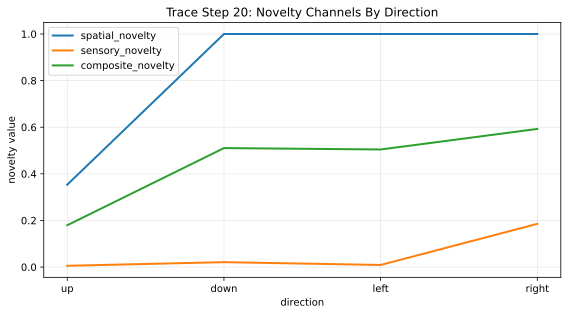

In [11]:
fig, ax = lines_plot(
    [
        {'x': trace_novelty_df['direction'], 'y': trace_novelty_df['spatial_novelty'], 'label': 'spatial_novelty'},
        {'x': trace_novelty_df['direction'], 'y': trace_novelty_df['sensory_novelty'], 'label': 'sensory_novelty'},
        {'x': trace_novelty_df['direction'], 'y': trace_novelty_df['composite_novelty'], 'label': 'composite_novelty'},
    ],
    title='Trace Step 20: Novelty Channels By Direction',
    xlabel='direction',
    ylabel='novelty value',
)


In [12]:
hunger_drive = HungerDrive(
    consume_weight=series_data[baseline_label]['config']['system']['policy']['consume_weight'],
    stay_suppression=series_data[baseline_label]['config']['system']['policy']['stay_suppression'],
    max_energy=series_data[baseline_label]['config']['system']['agent']['max_energy'],
)

obs = Observation(
    current=CellObservation(**baseline_decision['observation']['current']),
    up=CellObservation(**baseline_decision['observation']['up']),
    down=CellObservation(**baseline_decision['observation']['down']),
    left=CellObservation(**baseline_decision['observation']['left']),
    right=CellObservation(**baseline_decision['observation']['right']),
)
agent_state = AgentState(
    energy=baseline_trace['energy_before'],
    observation_buffer=ObservationBuffer(entries=(), capacity=1),
)
hunger_only = hunger_drive.compute(agent_state, obs)

combined_df = pd.DataFrame(
    {
        'action': ['up', 'down', 'left', 'right', 'consume', 'stay'],
        'hunger_contribution': hunger_only.action_contributions,
        'curiosity_contribution': baseline_decision['curiosity_drive']['action_contributions'],
        'combined_score': baseline_decision['combined_scores'],
        'selected': [a == baseline_decision['policy']['selected_action'] for a in ['up', 'down', 'left', 'right', 'consume', 'stay']],
    }
)

display(combined_df)


,action,hunger_contribution,curiosity_contribution,combined_score,selected
0,up,0.00,0.179527,0.028104,False
1,down,0.00,0.510500,0.079917,False
2,left,0.00,0.504500,0.078977,False
3,right,0.04,0.592750,0.096953,True
4,consume,0.00,-0.350000,-0.054791,False
5,stay,-0.02,-0.350000,-0.056871,False


This step shows a crucial point.

If we looked only at hunger, the rightward resource signal would matter, but the non-resource directions would stay tied near zero. Curiosity changes that geometry by assigning differentiated movement value even to directions without immediate reward.

That is why exploration in AXIS is not random.

It is a shaped preference field generated from:

- familiarity structure in the visit-count world model
- recent sensory change in the observation buffer
- blending of those two novelty channels
- arbitration with hunger


## A Small Real World-Model Snapshot

The next plot uses the actual `visit_counts_map` from the same trace step. This is not the whole world. It is the agent-relative familiarity structure accumulated so far.


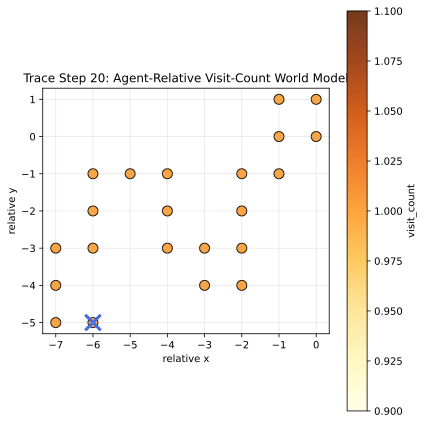

In [13]:
visit_df = pd.DataFrame(
    [
        {'x': pos[0], 'y': pos[1], 'visit_count': count}
        for pos, count in baseline_trace['visit_counts_map']
    ]
)

plt = __import__('matplotlib.pyplot').pyplot
fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(
    visit_df['x'],
    visit_df['y'],
    s=80 + 20 * visit_df['visit_count'],
    c=visit_df['visit_count'],
    cmap='YlOrBr',
    edgecolors='black',
    alpha=0.9,
)
ax.scatter([baseline_trace['relative_position'][0]], [baseline_trace['relative_position'][1]], s=240, marker='x', color='royalblue', linewidths=3)
ax.set_title('Trace Step 20: Agent-Relative Visit-Count World Model')
ax.set_xlabel('relative x')
ax.set_ylabel('relative y')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')
fig.colorbar(scatter, ax=ax, label='visit_count')
fig.tight_layout()


The important interpretive point is that this structure is sufficient to induce novelty gradients without being a semantic map. The agent knows where it has been more or less often, not where "good places" are in any explicit representational sense.


## What The Series Says About Different Curiosity Regimes

The `curiosity-arbitration` series lets us move beyond one trace and ask how different curiosity settings reshape behavior across many episodes.

For this notebook, the most relevant comparison set is:

- `aw-a-reduction-check`: curiosity effectively removed
- `aw-baseline`: balanced mixed curiosity
- `aw-exploration-biased`: stronger curiosity pressure
- `aw-spatial-novelty-dominant`: stronger familiarity-seeking in space
- `aw-sensory-novelty-dominant`: stronger sensitivity to changing local stimuli

Because these series runs were rerun at a **400-step horizon**, they are more informative about whether a curiosity regime merely looks active early on or remains behaviorally viable over a longer episode.


In [14]:
series_rows = []
for label in selected_labels:
    item = series_data[label]
    summary = item['summary']['run_summary']
    metrics = item['behavior_metrics']['system_specific_metrics']
    series_rows.append(
        {
            'label': label,
            'experiment_id': item['experiment_id'],
            'death_rate': summary['death_rate'],
            'mean_steps': summary['mean_steps'],
            'mean_final_vitality': summary['mean_final_vitality'],
            'curiosity_pressure_rate': metrics['system_aw_curiosity']['curiosity_pressure_rate'],
            'mean_spatial_novelty': metrics['system_aw_curiosity']['mean_spatial_novelty'],
            'mean_sensory_novelty': metrics['system_aw_curiosity']['mean_sensory_novelty'],
            'world_model_unique_cells': metrics['system_aw_world_model']['world_model_unique_cells'],
            'world_model_revisit_ratio': metrics['system_aw_world_model']['world_model_revisit_ratio'],
            'curiosity_led_move_rate': metrics['system_aw_behavior']['curiosity_led_move_rate'],
        }
    )

series_df = pd.DataFrame(series_rows)
display(series_df)

,label,experiment_id,death_rate,mean_steps,mean_final_vitality,curiosity_pressure_rate,mean_spatial_novelty,mean_sensory_novelty,world_model_unique_cells,world_model_revisit_ratio,curiosity_led_move_rate
0,aw-a-reduction-check,d399e549ce624851ad46de2b8aa6ae84,0.62,264.24,0.27649,0.000000,0.498101,0.053387,59.26,0.749448,0.000000
1,aw-baseline,f6007c77281445359cd80f28805f8f35,0.62,293.16,0.23836,0.260540,0.612977,0.171034,146.56,0.448213,0.260540
2,aw-exploration-biased,b9dd7afa48f04cf5be38754a7792b713,0.56,272.18,0.22015,0.609450,0.576671,0.189155,131.80,0.436841,0.597619
3,aw-spatial-novelty-dominant,d3545525ae5c45f994d87f6f8dd64bb8,0.92,216.66,0.03803,0.464322,0.653098,0.118268,144.60,0.285559,0.460445
4,aw-sensory-novelty-dominant,bee2ea945d4f4f42b19eba41d940e903,0.44,310.40,0.28935,0.632668,0.549723,0.227508,102.32,0.591221,0.616753


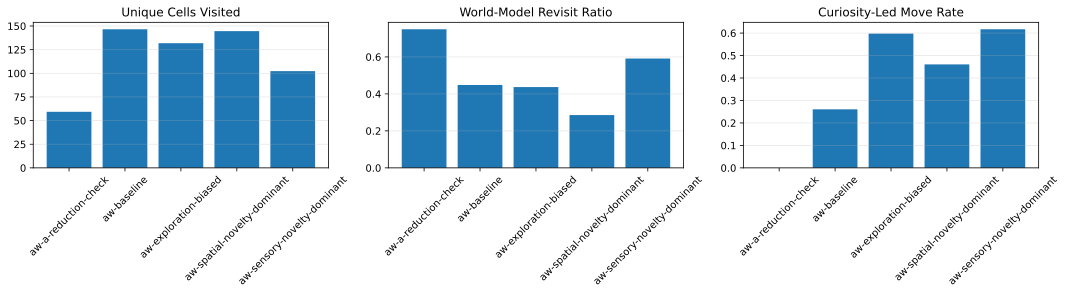

In [15]:
fig, axes = __import__('matplotlib.pyplot').pyplot.subplots(1, 3, figsize=(15, 4.2))
axes[0].bar(series_df['label'], series_df['world_model_unique_cells'])
axes[0].set_title('Unique Cells Visited')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(series_df['label'], series_df['world_model_revisit_ratio'])
axes[1].set_title('World-Model Revisit Ratio')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, axis='y', alpha=0.3)

axes[2].bar(series_df['label'], series_df['curiosity_led_move_rate'])
axes[2].set_title('Curiosity-Led Move Rate')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, axis='y', alpha=0.3)

fig.tight_layout()


These 400-step results make several points visible.

- removing curiosity does not make behavior collapse into randomness; it makes exploration pressure collapse back toward hunger-only structure
- stronger curiosity can raise curiosity-led movement without guaranteeing better long-horizon survival
- spatially dominant curiosity still produces broad low-revisit exploration, but in this baseline world it is now visibly the most fragile regime over longer episodes
- sensory-dominant curiosity produces a different footprint: less broad coverage than the spatially dominant variant, more revisitation, and substantially better long-horizon viability in this rerun

That is exactly why the AXIS model should not be read as "the" curiosity mechanism. Even within this one family, different novelty constructions already generate meaningfully different behavioral signatures and different survival tradeoffs.


## Hunger-Curiosity Arbitration: Only What We Need Here

This notebook is mainly about curiosity itself, not about the full phase structure of drive arbitration. Still, one equation matters because curiosity is not allowed to act alone in `system_aw`.

The arbitration weights are:

$$
w_H(t) = w_H^{\text{base}} + (1 - w_H^{\text{base}}) \cdot d_H(t)^{\gamma}
$$

$$
w_C(t) = w_C^{\text{base}} \cdot (1 - d_H(t))^{\gamma}
$$

This means hunger increasingly gates curiosity as hunger activation rises.

That is why curiosity is most visible when the agent has enough energetic slack to explore. The full behavioral consequences of this will be treated more directly in the later notebook on arbitration and behavioral phases.



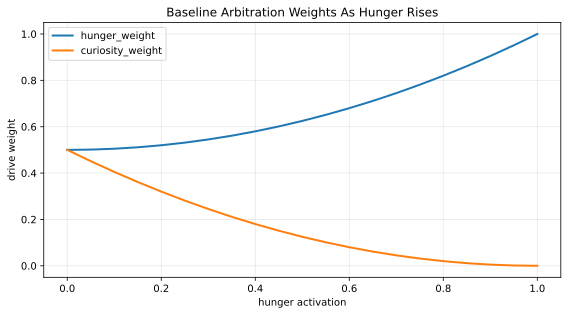

In [16]:
hunger_values = [i / 20 for i in range(21)]
weights_df = pd.DataFrame({'hunger_activation': hunger_values})
weights_df['baseline_hunger_weight'] = [
    compute_maslow_weights(
        h,
        primary_weight_base=series_data[baseline_label]['config']['system']['arbitration']['hunger_weight_base'],
        secondary_weight_base=series_data[baseline_label]['config']['system']['arbitration']['curiosity_weight_base'],
        gating_sharpness=series_data[baseline_label]['config']['system']['arbitration']['gating_sharpness'],
    ).hunger_weight
    for h in hunger_values
]
weights_df['baseline_curiosity_weight'] = [
    compute_maslow_weights(
        h,
        primary_weight_base=series_data[baseline_label]['config']['system']['arbitration']['hunger_weight_base'],
        secondary_weight_base=series_data[baseline_label]['config']['system']['arbitration']['curiosity_weight_base'],
        gating_sharpness=series_data[baseline_label]['config']['system']['arbitration']['gating_sharpness'],
    ).curiosity_weight
    for h in hunger_values
]

fig, ax = lines_plot(
    [
        {'x': weights_df['hunger_activation'], 'y': weights_df['baseline_hunger_weight'], 'label': 'hunger_weight'},
        {'x': weights_df['hunger_activation'], 'y': weights_df['baseline_curiosity_weight'], 'label': 'curiosity_weight'},
    ],
    title='Baseline Arbitration Weights As Hunger Rises',
    xlabel='hunger activation',
    ylabel='drive weight',
)


## Closing Perspective

The central message of this notebook is that exploration in AXIS is not a random residue left over after hunger.

It is produced by explicit novelty gradients derived from:

- a visit-count world model
- an observation buffer
- a spatial/sensory blend
- a curiosity activation term
- and a visible arbitration relation with hunger

That makes curiosity in `system_aw` both limited and powerful.

It is limited because it is only one mechanistic realization of curiosity, not a universal account of epistemic behavior.
It is powerful because even this constrained realization already generates structured exploratory behavior that can be inspected mathematically, visually, and trace-by-trace.
